In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay

In [12]:
df=pd.read_csv("heart disease dataset.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [13]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [14]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

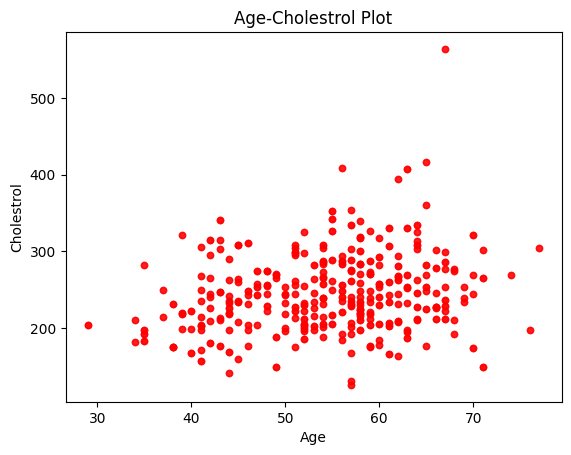

In [15]:
df.plot(kind='scatter', x='age', y='chol', alpha=0.5, color='red')
plt.xlabel('Age')
plt.ylabel('Cholestrol')
plt.title('Age-Cholestrol Plot')
plt.show()

In [16]:
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

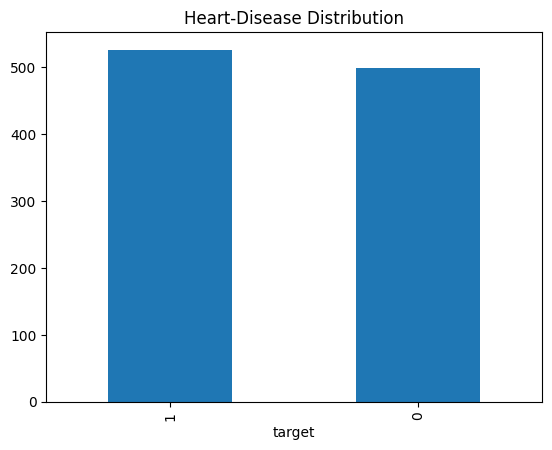

In [17]:
df['target'].value_counts().plot(kind='bar')
plt.title("Heart-Disease Distribution")
plt.show()

In [18]:
X=df.drop('target',axis=1)
Y=df.target

In [19]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [21]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [23]:
ml=svm.SVC()

param_grid={
    'C':[0.1, 1, 10],
    'gamma':['scale', 0.1, 0.01],
    'kernel':['linear', 'rbf']
}

grid=GridSearchCV(ml, param_grid, refit=True, verbose=1, cv=15)
grid_search=grid.fit(X_train, Y_train)

Fitting 15 folds for each of 18 candidates, totalling 270 fits


In [25]:
print(grid_search.best_params_)

{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


In [26]:
accuracy=grid_search.best_score_*100
print("accuracy for our training dataset with tuning is:{:.2f}%".format(accuracy))

accuracy for our training dataset with tuning is:98.17%


In [28]:
Y_pred=grid.predict(X_test)
test_accuracy=accuracy_score(Y_test, Y_pred)*100
test_accuracy
print("Accuracy for our testing dataset with tuning is: {:.2f}"

98.53658536585365

In [29]:
confusion_matrix=metrics.confusion_matrix(Y_test, Y_pred)
cm_display=metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=[True, False])

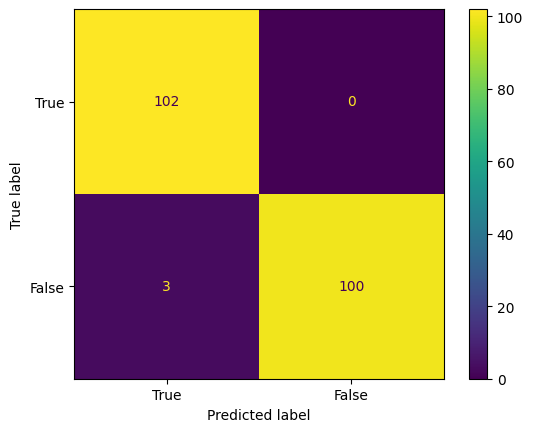

In [30]:
cm_display.plot()
plt.show()

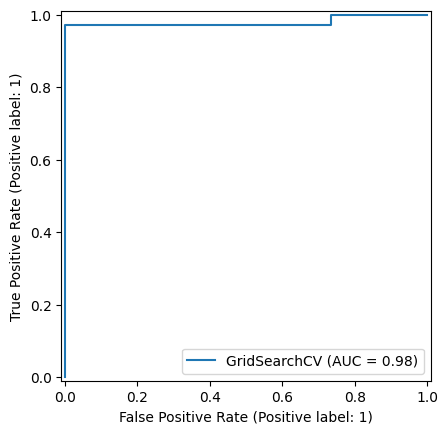

In [33]:
RocCurveDisplay.from_estimator(grid, X_test, Y_test)